In [1]:
import cv2
import json
import pickle
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split
from typing import List, Tuple
from tqdm import tqdm
from models import StackedHourglassCBAM
from utils import softargmax_2d
random.seed(41) # 10, 11, 12
device = torch.device("cuda:0")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# with open("pickle/folds.pkl", "rb") as f:
#     folds = pickle.load(f)

# exclude_idx = 0
# train_data = sum([fold for i, fold in enumerate(folds) if i != exclude_idx], [])
# val_data = folds[exclude_idx]
# random.shuffle(train_data)
# random.shuffle(val_data)

In [2]:
with open("pickle/train.pkl", "rb") as f:
    train_data = pickle.load(f)
random.shuffle(train_data)
with open("pickle/val.pkl", "rb") as f:
    val_data = pickle.load(f)

with open("pickle/test.pkl", "rb") as f:
    test_data = pickle.load(f)

print(len(train_data))
print(len(val_data))
print(len(test_data))

1600
200
200


In [3]:
def apply_crop(image, center, crop_size):

    H, W = image.shape

    if H > 5500:
        crop_size = (crop_size[0] * 2, crop_size[1] * 2)    
    
    half = (crop_size[0] // 2, crop_size[1] // 2)

    x_center, y_center = center

    # Ensure coordinates stay within bounds
    x_center = np.clip(x_center, half[1], W - half[1])
    y_center = np.clip(y_center, half[0], H - half[0])

    # Bounding box coordinates
    x1 =int(max(0, x_center - half[1]))
    y1 = int(max(0, y_center - half[0]))
    x2 = int(min(W, x_center + half[1]))
    y2 = int(min(H, y_center + half[0]))
    
    cropped_image = image[y1:y2, x1:x2]
    
    return cropped_image, (x1, y1)

In [4]:
def generate_heatmap(size_hw: Tuple[int, int], center_xy: Tuple[float, float], sigma: float = 2.0):
    """Create a single 2D gaussian heatmap (H,W) with center (x,y) in pixel coords."""
    W, H = size_hw[1], size_hw[0]
    y = torch.arange(H, dtype=torch.float32)
    x = torch.arange(W, dtype=torch.float32)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    cx, cy = center_xy
    hm = torch.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))
    return hm

In [5]:
class CustomDataset(Dataset):
    def __init__(self, data, image_size=(512, 512), heatmap_size=(128, 128), crop_size=(512, 512), sigma=2, train=False):
        self.data = data
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.crop_size = crop_size
        self.sigma = sigma
        self.train = train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, keypoints = self.data[idx]
        image_array = np.fromfile(image_path, dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Failed to read image at {image_path}")
        H, W = image.shape

        if self.train:
            
            if random.random() < 0.5:
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                image = clahe.apply(image)
            # Brightness augmentation
            if random.random() < 0.5:
                factor = random.uniform(0.9, 1.1)  # brightness factor
                image = np.clip(image * factor, 0, 255).astype(np.uint8)

            if random.random() < 0.5:
                if random.random() < 0.5:
                    #print(f"SHARPEN")
                    kernel = np.array([[0, -1, 0],
                                [-1, 5, -1],
                                [0, -1, 0]])
                    
                    sharpened  = cv2.filter2D(image, -1, kernel)
                    alpha = random.uniform(0.1, 0.4)  # blend factor
                    image = cv2.addWeighted(sharpened, alpha, image, 1 - alpha, 0)
            
                else:
                    #print(f"BLUR")
                    ksize = random.choice([3, 5])
                    sigmaX = random.uniform(0.3, 1.0)
                    image = cv2.GaussianBlur(image, (ksize, ksize), sigmaX=sigmaX)
        
        keypoint = np.array((keypoints['R1'][0], H - keypoints['R1'][1]), dtype=np.float32)

        cropped_image, shift = apply_crop(image, keypoint, self.crop_size)

        resized_image = cv2.resize(cropped_image, (self.image_size[1], self.image_size[0]))

        target = keypoint - shift

        sx = self.heatmap_size[1] / cropped_image.shape[1]
        sy = self.heatmap_size[0] / cropped_image.shape[0]
    

        target[0] *= sx
        target[1] *= sy

        image_tensor = torch.from_numpy(resized_image).float().unsqueeze(0) / 255.0
        keypoint_tensor = torch.from_numpy(target).float()
        heatmap_tensor = generate_heatmap(self.heatmap_size, target, sigma=self.sigma).unsqueeze(0)
        meta = {"image_path": image_path}

        return image_tensor, keypoint_tensor, heatmap_tensor, meta

In [6]:
batch_size = 32
image_size = (384, 384)
heatmap_size = (96, 96)
crop_size = (384, 384)

train_dataset = CustomDataset(
    data=train_data, # data[:train_size]
    image_size=image_size,
    heatmap_size=heatmap_size,
    sigma=2,
    train=True # True
)

val_dataset = CustomDataset(
    data=val_data, # data[train_size:]
    image_size=image_size,
    heatmap_size=heatmap_size,
    sigma=2,
    train=False
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

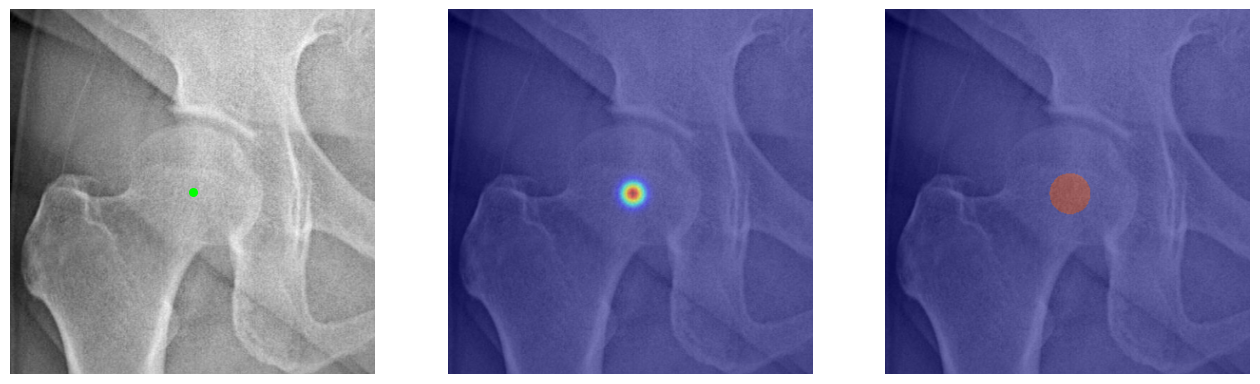

In [7]:
img, gt_kps, gt_hmps, meta = val_dataset[0]  

img = img.squeeze().numpy()

gt_kps = gt_kps.numpy()
gt_kps[0] *= 384/96
gt_kps[1] *= 384/96

gt_hmps = gt_hmps.numpy()
rgt_hmps = cv2.resize(gt_hmps[0], (384, 384)) # (512, 256)

fig, axes = plt.subplots(1, 3, figsize=(16, 16))

axes[0].imshow(img, cmap='gray')
axes[0].scatter(gt_kps[0], gt_kps[1], c='lime', marker='o', s=30)
axes[0].axis('off')

axes[1].imshow(img, cmap='gray')
axes[1].imshow(rgt_hmps, cmap='jet', alpha=0.5)
axes[1].axis('off')

axes[2].imshow(img, cmap='gray')
axes[2].imshow(rgt_hmps > 0.03, cmap='jet', alpha=0.5)
axes[2].axis('off')

plt.show()

In [8]:
model = StackedHourglassCBAM(num_keypoints=1, num_stacks=2, depth=4, channels=256, in_ch=1).to(device)
x = torch.rand(1, 1, 384, 384).to(device)
outs = model(x)
print([out.shape for out in outs])
print(f"Model params: {sum(p.numel() for p in model.parameters())}") 

[torch.Size([1, 1, 96, 96]), torch.Size([1, 1, 96, 96])]
Model params: 6725694


In [9]:
# model.load_state_dict(torch.load('saved/hourglass_cbam_mse[hip].pth'))
# model.to(device)
# model.eval()
# print("Loaded!")

Loaded!


/tmp/ipykernel_62420/2026747217.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('saved/hourglass_cbam_mse[hip].pth'))


In [9]:
class AdaptiveWingLoss(nn.Module):
    """
    Adaptive Wing Loss for heatmap regression.

    Paper: "Adaptive Wing Loss for Robust Face Alignment via Heatmap Regression" (ICCV 2019)

    Args:
        alpha (float): curvature control (>2), paper uses 2.1
        omega (float): scaling factor, paper uses 14.0
        epsilon (float): small constant, paper uses 1.0
        theta (float): transition between nonlinear / linear, paper uses 0.5
        reduction (str): 'mean', 'sum', or 'none'
    """
    def __init__(
        self,
        alpha: float = 2.1,
        omega: float = 14.0,
        epsilon: float = 1.0,
        theta: float = 0.5,
        reduction: str = "mean",
    ):
        super().__init__()
        assert reduction in ("mean", "sum", "none")
        self.alpha = alpha
        self.omega = omega
        self.epsilon = epsilon
        self.theta = theta
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred:   predicted heatmaps, shape (N, C, H, W) or similar
        target: ground truth heatmaps, same shape, values typically in [0, 1]
        """
        if pred.shape != target.shape:
            raise ValueError(f"Shape mismatch: pred {pred.shape}, target {target.shape}")

        # For AMP stability, compute in float32
        y_hat = pred.float()
        y = target.float()

        omega = self.omega
        theta = self.theta
        eps = self.epsilon
        alpha = self.alpha

        # |y - y^|
        delta = torch.abs(y - y_hat)

        # exponent = α - y  (adaptive to GT intensity)
        exponent = alpha - y  # same shape as y

        # Prepare base tensor for (θ/ε)^(α - y)
        theta_over_eps = theta / eps
        base = torch.full_like(y, theta_over_eps)

        t = torch.pow(base, exponent)  # (θ/ε)^(α - y)

        # A and C for linear branch (ensuring continuity & smoothness)
        A = omega * (1.0 / (1.0 + t)) * exponent * torch.pow(base, exponent - 1.0) * (1.0 / eps)
        C = theta * A - omega * torch.log(1.0 + t)

        # Mask: small vs large error
        small_err = delta < theta

        # Nonlinear part: ω * log(1 + (|y - y^| / ε)^(α - y))
        delta_over_eps = delta / eps
        loss_small = omega * torch.log(1.0 + torch.pow(delta_over_eps, exponent))

        # Linear part: A * |y - y^| - C
        loss_large = A * delta - C

        loss = torch.where(small_err, loss_small, loss_large)

        # reduction
        if self.reduction == "mean":
            loss = loss.mean()
        elif self.reduction == "sum":
            loss = loss.sum()
        # else: 'none' → return per-pixel loss

        # Match original dtype (useful with AMP)
        return loss.to(pred.dtype)

In [10]:
train_losses, val_losses = [], []

num_epochs = 100
warmup_epochs = 4
base_lr = 3e-4 #3e-4
weight_decay = 1e-4
grad_clip_norm  = 1.0
use_amp = True
model_path = "saved/hourglass_cbam[hip].pth"

#criterion = nn.MSELoss()
criterion = AdaptiveWingLoss(
    alpha=2.1,
    omega=14.0,
    epsilon=1.0,
    theta=0.5,
    reduction="mean",
)

optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
scaler = GradScaler(enabled=use_amp)

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        # Linear warmup
        return float(current_epoch + 1) / float(warmup_epochs)
    else:
        # Cosine decay
        progress = (current_epoch - warmup_epochs) / float(num_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val_loss = float('inf')
epochs_no_improve = 0
early_stopping_patience = 5


for epoch in range(num_epochs):
    model.train()

    train_loss = 0

    for images, _, heatmaps, _ in tqdm(train_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Training"):
        images = images.to(device, non_blocking=True)
        heatmaps = heatmaps.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            outputs = model(images)
            #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
            loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)

        if use_amp:
            scaler.scale(loss).backward()
            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            # Clip the gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            # Then optimizer step
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_pix_err = 0
    with torch.no_grad():
        for images, keypoints, heatmaps, _ in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{num_epochs}] Validation"):
            images = images.to(device, non_blocking=True)
            gt_xy = keypoints.to(device, non_blocking=True).float()
            heatmaps = heatmaps.to(device, non_blocking=True).float()

            with autocast(enabled=use_amp):
                outputs = model(images)
                #loss = sum(w * criterion(o, heatmaps) for w, o in zip(head_weights, outputs))
                loss = sum(criterion(o, heatmaps) for o in outputs) / len(outputs)
                
                #loss = criterion(outputs, heatmaps)
                # pred_xy = decode_argmax(outputs[-1])
                # batch_err = pck_like_err(pred_xy, gt_xy)
                # val_pix_err += batch_err.item()

                pred_xy = softargmax_2d(outputs[-1], beta=100.0).squeeze(1)
            batch_err = torch.linalg.vector_norm(pred_xy - gt_xy, dim=-1).mean().item()
            
            val_loss += loss.item()
            val_pix_err += batch_err

    val_loss /= len(val_loader)
    val_pix_err /= len(val_loader)
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} ➤ Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | mean_pixel_err: {val_pix_err:.2f}")

    # Early Stopping & Save Best
    if val_loss < best_val_loss:
        print(f"🟢 New best model (val_loss: {val_loss:.6f} < {best_val_loss:.6f}) — saving to {model_path}")
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"🔴 No improvement for {epochs_no_improve} epoch(s)")
    
    if epochs_no_improve >= early_stopping_patience:
        print("⏹ Early stopping triggered.")
        break

/tmp/ipykernel_747/1932234828.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
[Epoch 1/100] Training:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_747/1932234828.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation:   0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipykernel_747/1932234828.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
[Epoch 1/100] Validation: 100%|██████████| 7/7 [00:06<00:00,  1.03it/s]


Epoch 1/100 ➤ Train Loss: 0.731931 | Val Loss: 0.028268 | mean_pixel_err: 7.70
🟢 New best model (val_loss: 0.028268 < inf) — saving to saved/hourglass_cbam[hip].pth


[Epoch 2/100] Validation: 100%|██████████| 7/7 [00:06<00:00,  1.15it/s]


Epoch 2/100 ➤ Train Loss: 0.103431 | Val Loss: 0.144191 | mean_pixel_err: 14.60
🔴 No improvement for 1 epoch(s)


[Epoch 3/100] Validation: 100%|██████████| 7/7 [00:07<00:00,  1.05s/it]


...

Epoch 30/100 ➤ Train Loss: 0.000567 | Val Loss: 0.001234 | mean_pixel_err: 1.28
🔴 No improvement for 3 epoch(s)


[Epoch 31/100] Validation: 100%|██████████| 7/7 [00:06<00:00,  1.13it/s]


Epoch 31/100 ➤ Train Loss: 0.000572 | Val Loss: 0.001419 | mean_pixel_err: 0.70
🔴 No improvement for 4 epoch(s)


[Epoch 32/100] Validation: 100%|██████████| 7/7 [00:05<00:00,  1.31it/s]

Epoch 32/100 ➤ Train Loss: 0.000517 | Val Loss: 0.001183 | mean_pixel_err: 0.83
🔴 No improvement for 5 epoch(s)
⏹ Early stopping triggered.


dataset/2019_09월/0410 이종수_KP/M2/이종수1.jpg
83.16339


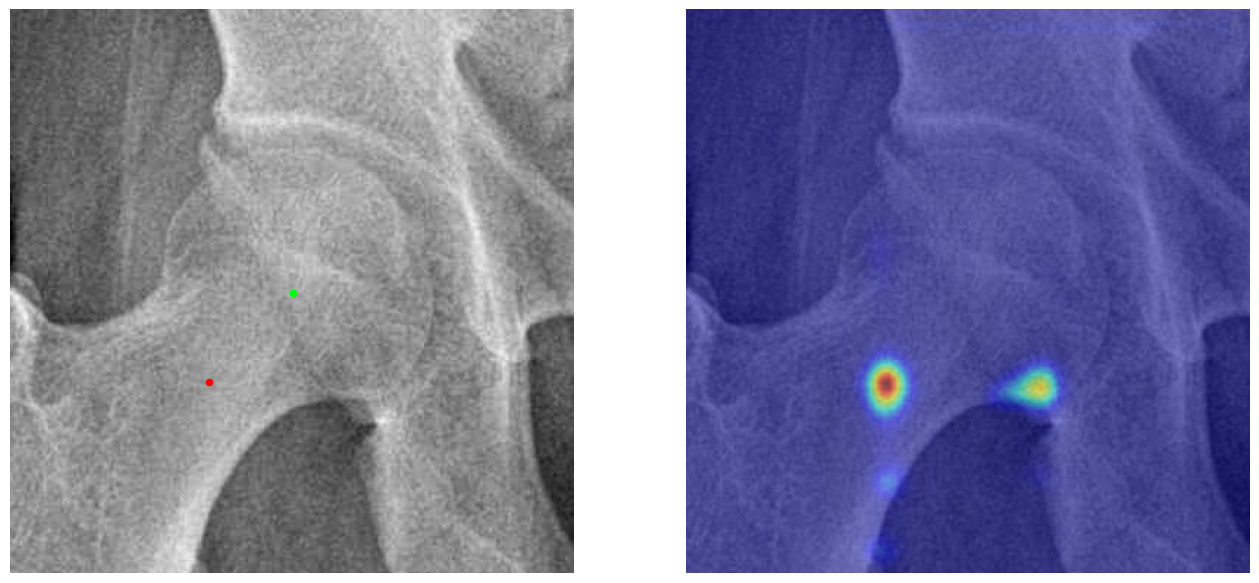

In [10]:
idx = 0
img, gt_kps, gt_hmps, meta = val_dataset[idx]

print(meta['image_path'])

with torch.no_grad():
    x = img.unsqueeze(0).to(device)
    outs = model(x)
    #p_hmps_up = F.interpolate(p_hmps[-1], size=(512, 512), mode='bilinear', align_corners=False)

p_hmp = outs[-1]
p_kps = softargmax_2d(p_hmp, beta=100.0)  # (1, 12, 2)
p_kps = p_kps.squeeze().cpu().numpy()

p_kps[0] *= 384 / 96
p_kps[1] *= 384 / 96

p_hmp = p_hmp.squeeze().cpu().numpy()
r_hmp = cv2.resize(p_hmp, (384, 384))

img = img.squeeze().numpy()
gt_kps = gt_kps.numpy()
gt_kps[0] *= 384 / 96
gt_kps[1] *= 384 / 96

dist = np.linalg.norm(gt_kps - p_kps)

print(dist)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img, cmap='gray')
axes[0].scatter(gt_kps[0], gt_kps[1], c='lime', marker='o', s=20)
axes[0].scatter(p_kps[0], p_kps[1], c='red', marker='o', s=20)
 
axes[1].imshow(img, cmap='gray')
axes[1].imshow(r_hmp, cmap='jet', alpha=0.5)

for ax in axes:
    ax.axis('off')
plt.show()

# [2.5204163 1.0026113 2.8162513 8.15204   1.1367732 8.030139  7.6611757
#  3.1140485 5.911936  4.752094  8.985992  7.1919   ]